In [4]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm
from tensorflow.keras.applications.vgg16 import VGG16,preprocess_input
from tensorflow.keras.preprocessing.image import load_img,img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical,plot_model
from tensorflow.keras.layers import Input,Dense,LSTM,Embedding,Dropout,add

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
BASE_DIR = '/content/drive/MyDrive/Flickr8k'
WORKING_DIR = '/content/drive/MyDrive/Flickr8k_model'

In [7]:
import os
os.listdir(BASE_DIR)


['captions.txt', 'Images']

In [8]:
import os
os.listdir(WORKING_DIR)

['features.pkl', 'captions_doc.pkl', 'mapping.pkl']

Extract image features

In [9]:
model=VGG16()
model=Model(inputs=model.inputs,outputs=model.layers[-2].output)
print(model.summary())

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
# extract features from image
features={}
directory=os.path.join(BASE_DIR,'Images')
for img_name in tqdm(os.listdir(directory)):
  img_path=directory+'/'+img_name
  image=load_img(img_path,target_size=(224,224))
  image=img_to_array(image)
  image=image.reshape((1,image.shape[0],image.shape[1],image.shape[2]))
  # preprocess image for VGG
  image=preprocess_input(image)
  feature=model.predict(image,verbose=0)
  image_id=img_name.split('.')[0]
  features[image_id]=feature

"# extract features from image\nfeatures={}\ndirectory=os.path.join(BASE_DIR,'Images')\nfor img_name in tqdm(os.listdir(directory)):\n  img_path=directory+'/'+img_name\n  image=load_img(img_path,target_size=(224,224))\n  image=img_to_array(image)\n  image=image.reshape((1,image.shape[0],image.shape[1],image.shape[2]))\n  # preprocess image for VGG\n  image=preprocess_input(image)\n  feature=model.predict(image,verbose=0)\n  image_id=img_name.split('.')[0]\n  features[image_id]=feature"

In [11]:
# store features in pickle
pickle.dump(features,open(os.path.join(WORKING_DIR,'features.pkl'),'wb'))

"# store features in pickle\npickle.dump(features,open(os.path.join(WORKING_DIR,'features.pkl'),'wb'))"

**👉 load features from pickle**

In [12]:
with open(os.path.join(WORKING_DIR,'features.pkl'),'rb') as f:
  features=pickle.load(f)

Load the captions Data

In [13]:
with open(os.path.join(BASE_DIR,'captions.txt'),'r') as f:
  next(f)
  captions_doc=f.read()

In [14]:
pickle.dump(captions_doc,open(os.path.join(WORKING_DIR,'captions_doc.pkl'),'wb'))

**👉 load captions_doc from pickle**

In [15]:
with open(os.path.join(WORKING_DIR,'captions_doc.pkl'),'rb') as f:
  captions_doc=pickle.load(f)

In [16]:
mapping={}
for line in tqdm(captions_doc.split('\n')):
  tokens=line.split(',')
  if len(line)<2:
    continue
  image_id,caption=tokens[0],tokens[1:]
  image_id=image_id.split('.')[0]
  caption=' '.join(caption)
  if image_id not in mapping:
    mapping[image_id]=[]
  mapping[image_id].append(caption)

  0%|          | 0/40456 [00:00<?, ?it/s]

In [17]:
len(mapping)

8091

In [18]:
pickle.dump(mapping,open(os.path.join(WORKING_DIR,'mapping.pkl'),'wb'))

**👉 load mapping from pickle**

In [19]:
with open(os.path.join(WORKING_DIR,'mapping.pkl'),'rb') as f:
  mapping=pickle.load(f)

In [20]:
import re

def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            caption = captions[i]
            caption = caption.lower()
            caption = re.sub(r'[^a-zA-Z ]', '', caption)
            caption = re.sub(r'\s+', ' ', caption)
            caption = " ".join([word for word in caption.split() if len(word) > 1])
            caption = 'startseq ' + caption + ' endseq'
            captions[i] = caption

In [21]:
mapping['1000268201_693b08cb0e']

['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .']

In [22]:
clean(mapping)

In [23]:
mapping['1000268201_693b08cb0e']

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq']

In [24]:
all_captions=[]
for key in mapping:
  for caption in mapping[key]:
    all_captions.append(caption)

In [25]:
len(all_captions)

40455

In [26]:
all_captions[:5]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq']

In [27]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size=len(tokenizer.word_index)+1

In [28]:
vocab_size

8768

In [29]:
max_length=max(len(caption.split()) for caption in all_captions)
max_length

34

Train Test Split

In [30]:
image_ids=list(mapping.keys())
split=int(len(image_ids)*0.90)
train=image_ids[:split]
test=image_ids[split:]

In [31]:
def data_generator(data_keys, mapping, features,
                   tokenizer, max_length,
                   vocab_size, batch_size):

    x1, x2, y = list(), list(), list()
    n = 0

    while True:

        for key in data_keys:

            captions = mapping[key]
            n += 1

            for caption in captions:

                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):

                    in_seq, out_seq = seq[:i], seq[i]

                    in_seq = pad_sequences(
                        [in_seq],
                        maxlen=max_length,
                        padding='post'
                    )[0]

                    out_seq = to_categorical(
                        [out_seq],
                        num_classes=vocab_size
                    )[0]

                    x1.append(features[key][0])
                    x2.append(in_seq)
                    y.append(out_seq)

            if n == batch_size:

                x1 = np.array(x1)
                x2 = np.array(x2)
                y = np.array(y)

                yield (x1, x2), y

                x1, x2, y = list(), list(), list()
                n = 0

Model Creation

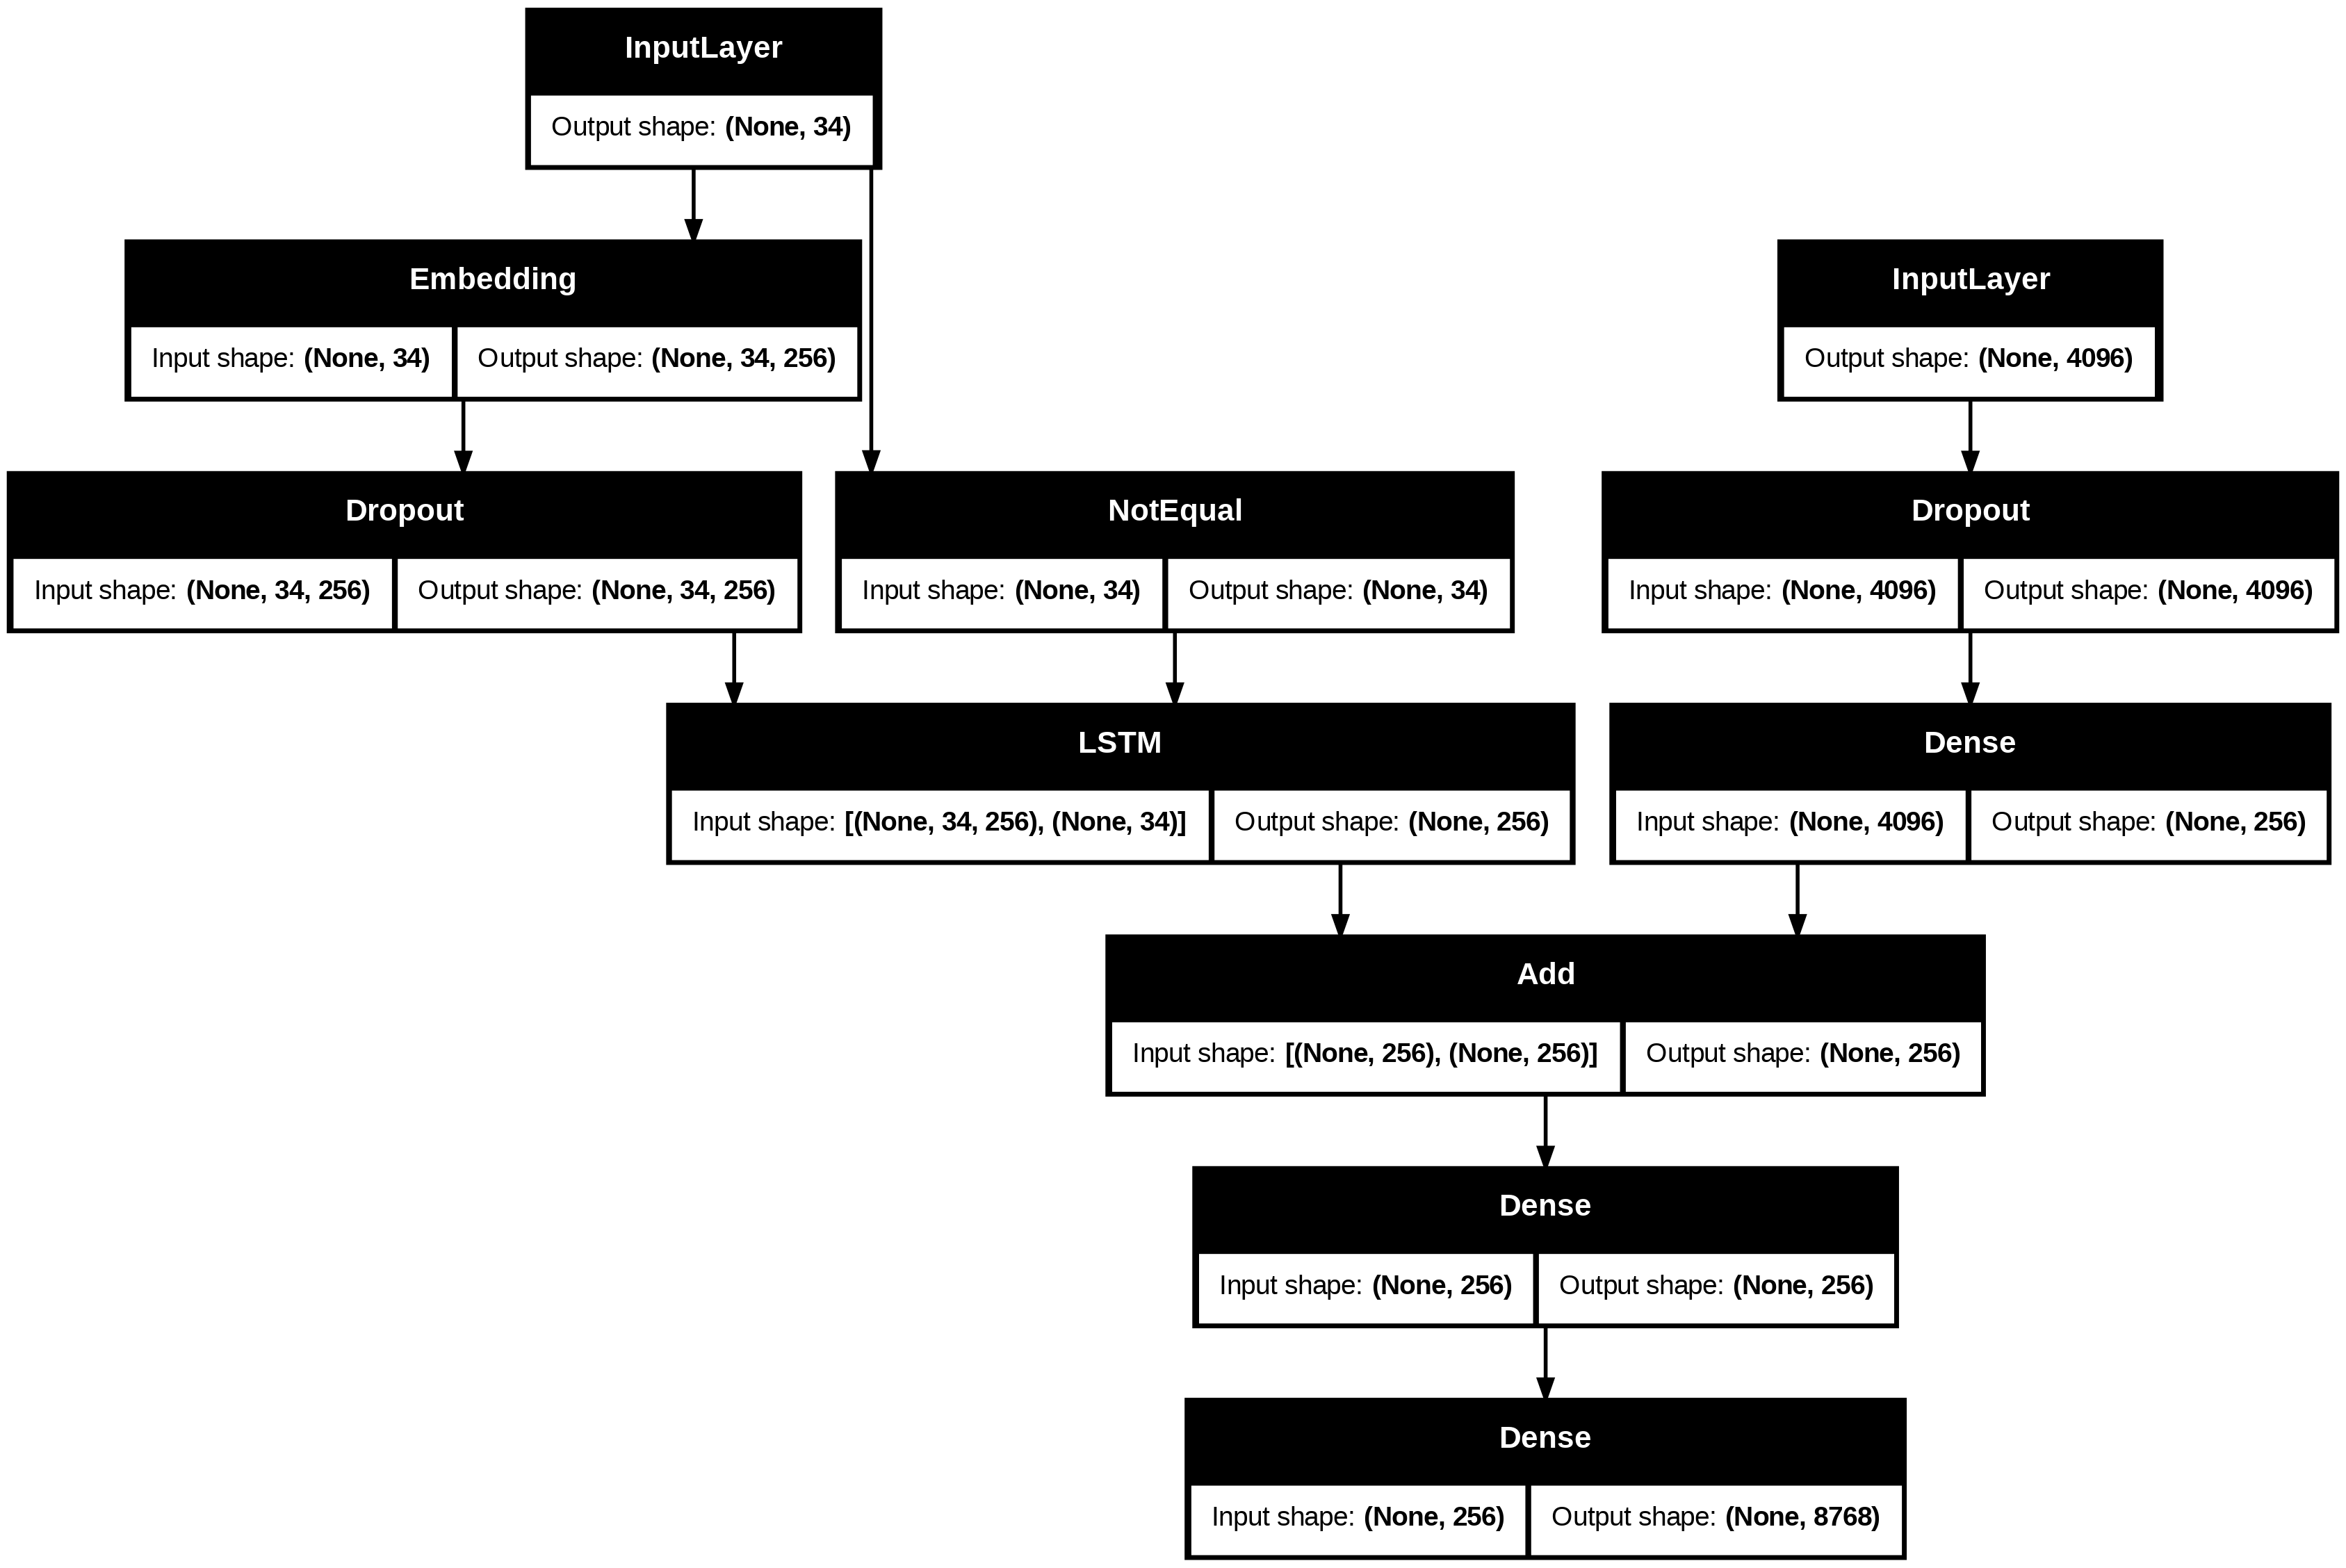

In [32]:
# encoder model
inputs1=Input(shape=(4096,))
fe1=Dropout(0.4)(inputs1)
fe2=Dense(256,activation='relu')(fe1)

inputs2=Input(shape=(max_length,))
se1=Embedding(vocab_size,256,mask_zero=True)(inputs2)
se2=Dropout(0.4)(se1)
se3=LSTM(256)(se2)

# decoder model
decoder1=add([fe2,se3])
decoder2=Dense(256,activation='relu')(decoder1)
outputs=Dense(vocab_size,activation='softmax')(decoder2)

model=Model(inputs=[inputs1,inputs2],outputs=outputs)
model.compile(loss='categorical_crossentropy',optimizer='adam')

# plot the model
plot_model(model,show_shapes=True)

In [33]:
epochs=20
batch_size=32
steps = len(train)//batch_size
for i in range(epochs):
  generator=data_generator(train,mapping,features,tokenizer,max_length,vocab_size,batch_size)
  model.fit(generator,epochs=1,steps_per_epoch=steps,verbose=1)

227/227 ━━━━━━━━━━━━━━━━━━━━ 59s 240ms/step - loss: 5.1426
227/227 ━━━━━━━━━━━━━━━━━━━━ 55s 241ms/step - loss: 3.9171
227/227 ━━━━━━━━━━━━━━━━━━━━ 54s 236ms/step - loss: 3.5101
227/227 ━━━━━━━━━━━━━━━━━━━━ 53s 234ms/step - loss: 3.2493
227/227 ━━━━━━━━━━━━━━━━━━━━ 54s 236ms/step - loss: 3.0611
227/227 ━━━━━━━━━━━━━━━━━━━━ 52s 230ms/step - loss: 2.9186
227/227 ━━━━━━━━━━━━━━━━━━━━ 53s 232ms/step - loss: 2.8081
227/227 ━━━━━━━━━━━━━━━━━━━━ 53s 235ms/step - loss: 2.7147
227/227 ━━━━━━━━━━━━━━━━━━━━ 54s 236ms/step - loss: 2.6358
227/227 ━━━━━━━━━━━━━━━━━━━━ 54s 237ms/step - loss: 2.5651
227/227 ━━━━━━━━━━━━━━━━━━━━ 53s 234ms/step - loss: 2.5028
227/227 ━━━━━━━━━━━━━━━━━━━━ 55s 243ms/step - loss: 2.4510
227/227 ━━━━━━━━━━━━━━━━━━━━ 55s 240ms/step - loss: 2.4055
227/227 ━━━━━━━━━━━━━━━━━━━━ 55s 242ms/step - loss: 2.3614
227/227 ━━━━━━━━━━━━━━━━━━━━ 54s 240ms/step - loss: 2.3217
227/227 ━━━━━━━━━━━━━━━━━━━━ 55s 241ms/step - loss: 2.2879
227/227 ━━━━━━━━━━━━━━━━━━━━ 55s 241ms/step - loss: 2.25

In [34]:
model.save(WORKING_DIR+'/best_model.keras')

In [35]:
from tensorflow.keras.models import load_model
model = load_model(WORKING_DIR + '/best_model.keras')

Generate Captions for the image

In [36]:
index_word = {v:k for k,v in tokenizer.word_index.items()}

def idx_to_word(integer):
    return index_word.get(integer)

In [37]:
def predict_caption(model, image, tokenizer, max_length):

    in_text = 'startseq'

    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences(
            [sequence],
            maxlen=max_length,
            padding='post'
        )
        yhat = model.predict([image, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = idx_to_word(yhat)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break

    return in_text

Validate with test data

In [38]:
actual,predicted=list(),list()
for key in tqdm(test):
  captions=mapping[key]
  y_pred=predict_caption(model,features[key],tokenizer,max_length)
  actual_captions=[caption.split() for caption in captions]
  y_pred=y_pred.split()
  actual.append(actual_captions)
  predicted.append(y_pred)

  0%|          | 0/810 [00:00<?, ?it/s]

In [39]:
pickle.dump(actual,open(os.path.join(WORKING_DIR,'actual.pkl'),'wb'))
with open(os.path.join(WORKING_DIR,'actual.pkl'),'rb') as f:
  actual=pickle.load(f)

In [40]:
pickle.dump(predicted,open(os.path.join(WORKING_DIR,'predicted.pkl'),'wb'))
with open(os.path.join(WORKING_DIR,'predicted.pkl'),'rb') as f:
  predicted=pickle.load(f)

Calculate BLEU SCORE

In [41]:
from nltk.translate.bleu_score import corpus_bleu

print("BLEU-1: %f" % corpus_bleu(
    actual,
    predicted,
    weights=(1.0, 0, 0, 0)
))

print("BLEU-2: %f" % corpus_bleu(
    actual,
    predicted,
    weights=(0.5, 0.5, 0, 0)
))

print("BLEU-3: %f" % corpus_bleu(
    actual,
    predicted,
    weights=(0.33, 0.33, 0.33, 0)
))

print("BLEU-4: %f" % corpus_bleu(
    actual,
    predicted,
    weights=(0.25, 0.25, 0.25, 0.25)
))

BLEU-1: 0.533414
BLEU-2: 0.312566
BLEU-3: 0.196810
BLEU-4: 0.117063


Visualize the Results

In [42]:
from PIL import Image
import matplotlib.pyplot as plt
import os

def generate_caption(image_name):
    image_id = image_name.split('.')[0]
    img_path = os.path.join(BASE_DIR, "Images", image_name)
    image = Image.open(img_path)
    captions = mapping[image_id]

    print('------------------Actual Captions------------------')

    for caption in captions:
        print(caption)
    y_pred = predict_caption(
        model,
        features[image_id],
        tokenizer,
        max_length
    )

    print('\n------------------Predicted Caption------------------')
    print(y_pred)

    plt.imshow(image)
    plt.axis('off')
    plt.show()

------------------Actual Captions------------------
startseq black dog and spotted dog are fighting endseq
startseq black dog and tricolored dog playing with each other on the road endseq
startseq black dog and white dog with brown spots are staring at each other in the street endseq
startseq two dogs of different breeds looking at each other on the road endseq
startseq two dogs on pavement moving toward each other endseq

------------------Predicted Caption------------------
startseq two dogs are playing with each other on the sidewalk endseq


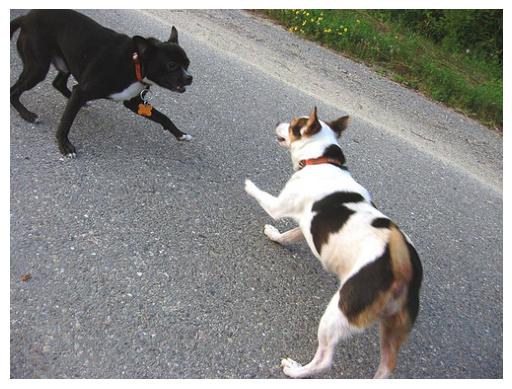

In [43]:
image_name = "1001773457_577c3a7d70.jpg"
generate_caption(image_name)

------------------Actual Captions------------------
startseq man at the top of mountain with beautiful view in the background endseq
startseq man is sitting on snowbank endseq
startseq man on snowy peak endseq
startseq person in red snow gear is kneeling on snowy ridge under blue sky endseq
startseq mountain climber in red suit poses on snowy peak with mountains in the background endseq

------------------Predicted Caption------------------
startseq man skiing down snowy hill endseq


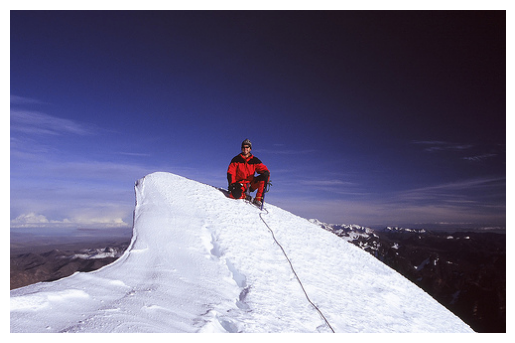

In [44]:
image_name = "55473406_1d2271c1f2.jpg"
generate_caption(image_name)

------------------Actual Captions------------------
startseq guy is riding bike up the side of hill endseq
startseq young man bicycles towards the camera and away from beautiful mountains on clear day endseq
startseq man on bike in mountains endseq
startseq man riding bicycle down narrow path endseq
startseq man riding bike on trail endseq

------------------Predicted Caption------------------
startseq man on bike rides through the air endseq


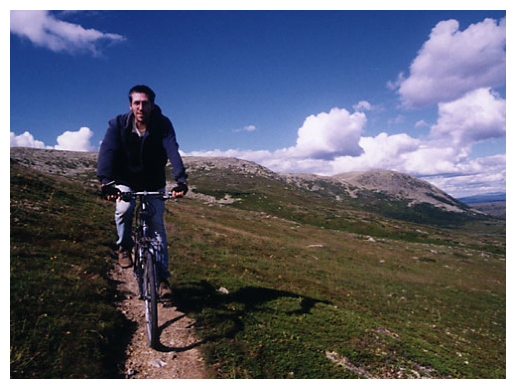

In [46]:
image_name = "95728660_d47de66544.jpg"
generate_caption(image_name)